# EDA: Silver Traffic Data

Exploratory Data Analysis on silver traffic data from MinIO via DuckDB.

**Prerequisites:** `make dev` running (MinIO, Nessie, Redpanda)

## 1. Setup & Connect

In [ ]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from urbanpulse_infra.duckdb import get_duckdb_connection
from urbanpulse_infra.iceberg import get_iceberg_catalog

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Install httpfs extension (only needed once on local machine)
_tmp = duckdb.connect()
_tmp.execute("INSTALL httpfs")
_tmp.close()

con = get_duckdb_connection(access_key="admin", secret_key="Abc@123456")

# Load Iceberg table to find actual data file locations
catalog = get_iceberg_catalog()
table = catalog.load_table("silver.traffic_route")

# Show where Iceberg actually stores its data files
print("=== Table location ===")
print(table.location())
print(f"\n=== Snapshots: {len(table.history())} ===")
print(f"Latest: {table.current_snapshot()}")
print("Connected to DuckDB + MinIO")

## 2. Load Data

In [ ]:
# Doc data qua PyIceberg (doc tu dung Iceberg location, khong phai path cu)
df = table.scan().to_pandas()

print(f"Shape: {df.shape}")
print(f"Date range: {df['timestamp_utc'].min()} → {df['timestamp_utc'].max()}")
df.head(10)

## 3. Basic Stats

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 415034 entries, 0 to 415033
Data columns (total 14 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   route_id                    412917 non-null  str           
 1   origin                      412917 non-null  str           
 2   destination                 412917 non-null  str           
 3   distance_meters             412917 non-null  float64       
 4   duration_ms                 412917 non-null  float64       
 5   duration_minutes            412917 non-null  float64       
 6   congestion_heavy_ratio      407678 non-null  float64       
 7   congestion_moderate_ratio   407678 non-null  float64       
 8   congestion_low_ratio        407678 non-null  float64       
 9   congestion_severe_segments  407678 non-null  Int32         
 10  congestion_total_segments   407678 non-null  Int32         
 11  timestamp_utc               412917 non-null  datet

In [4]:
df.describe()

,distance_meters,duration_ms,duration_minutes,congestion_heavy_ratio,congestion_moderate_ratio,congestion_low_ratio,congestion_severe_segments,congestion_total_segments,timestamp_utc
count,412917.000000,4.129170e+05,412917.000000,407678.000000,407678.000000,407678.000000,407678.0,407678.0,412917
mean,45498.629431,3.238104e+06,53.964364,0.107139,0.329804,0.531465,7.623487,355.640493,2026-02-14 14:36:44.530085
min,12205.610000,1.026755e+06,17.100000,0.020000,0.020000,0.000000,0.0,118.0,2026-01-26 17:45:53.938161
25%,18874.870000,1.408340e+06,23.500000,0.050000,0.100000,0.340000,0.0,185.0,2026-02-02 10:28:51.801023
50%,50988.840000,3.603400e+06,60.100000,0.080000,0.320000,0.570000,1.0,364.0,2026-02-09 14:59:34.988186
75%,58326.570000,4.650383e+06,77.500000,0.140000,0.510000,0.760000,10.0,451.0,2026-02-28 21:49:29.322739
max,105950.190000,7.468282e+06,124.500000,0.550000,0.850000,0.880000,63.0,895.0,2026-03-18 07:39:08.375134
std,24511.775634,1.667471e+06,27.790485,0.080513,0.207731,0.240504,11.264216,177.997585,NaN


In [5]:
# Null counts
print("=== Null counts ===")
print(df.isnull().sum())

print(f"\n=== Unique routes: {df['route_id'].nunique()} ===")
print(df['route_id'].value_counts())

=== Null counts ===
route_id                      2117
origin                        2117
destination                   2117
distance_meters               2117
duration_ms                   2117
duration_minutes              2117
congestion_heavy_ratio        7356
congestion_moderate_ratio     7356
congestion_low_ratio          7356
congestion_severe_segments    7356
congestion_total_segments     7356
timestamp_utc                 2117
source                        2117
date                          2117
dtype: int64

=== Unique routes: 20 ===
route_id
zone1_urban_core_to_zone2_eastern_innovation             20714
zone3_northern_industrial_to_zone4_southern_port         20707
zone2_eastern_innovation_to_zone3_northern_industrial    20705
zone1_urban_core_to_zone3_northern_industrial            20700
zone4_southern_port_to_zone5_western_periurban           20695
zone5_western_periurban_to_zone6_southern_coastal        20688
zone4_southern_port_to_zone1_urban_core                  20688


## 4. Data Quality Check

In [6]:
quality = con.execute(f"""
    SELECT
        COUNT(*)                                                       AS total_rows,
        COUNT(DISTINCT route_id)                                       AS unique_routes,
        MIN(timestamp_utc)                                             AS earliest,
        MAX(timestamp_utc)                                             AS latest,
        SUM(CASE WHEN timestamp_utc IS NULL THEN 1 ELSE 0 END)        AS null_timestamps,
        SUM(CASE WHEN duration_minutes <= 0 THEN 1 ELSE 0 END)        AS invalid_durations,
        SUM(CASE WHEN congestion_heavy_ratio IS NULL THEN 1 ELSE 0 END) AS null_congestion
    FROM read_parquet('{SILVER_PATH}', hive_partitioning := true)
""").df()

quality.T

,0
total_rows,415034
unique_routes,20
earliest,2026-01-26 17:45:53.938161
latest,2026-03-18 07:39:08.375134
null_timestamps,2117.0
invalid_durations,0.0
null_congestion,7356.0


## 5. Temporal Patterns

Xem data phan bo theo thoi gian.

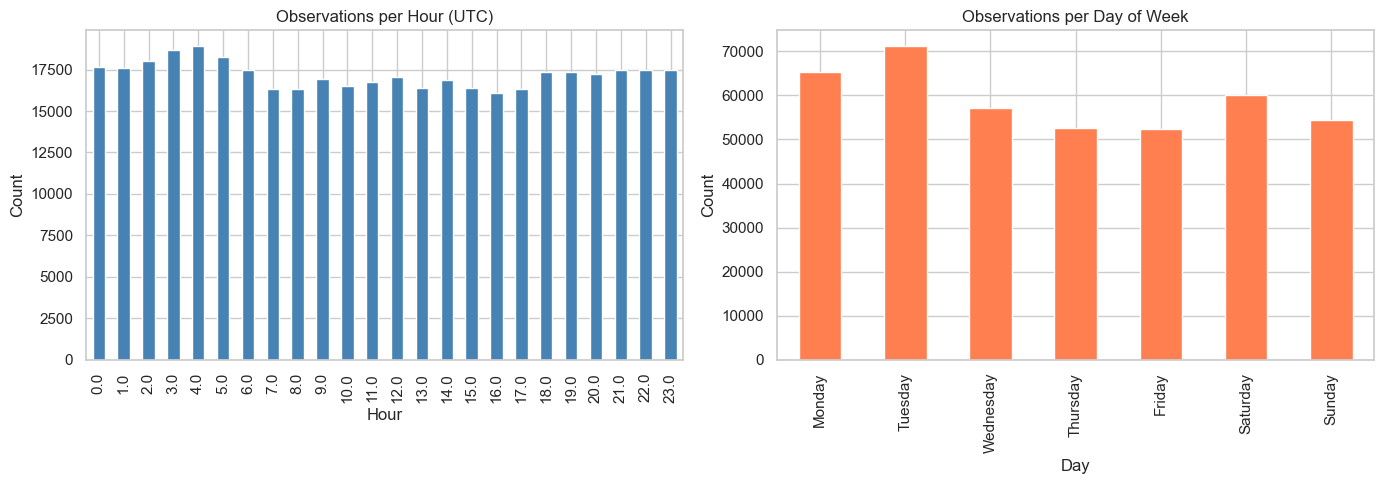

In [7]:
df["hour"] = df["timestamp_utc"].dt.hour
df["day_of_week"] = df["timestamp_utc"].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Observations per hour
df.groupby("hour").size().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Observations per Hour (UTC)")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Count")

# Observations per day of week
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df.groupby("day_of_week").size().reindex(dow_order).plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Observations per Day of Week")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 6. Duration Distribution

Feature quan trong nhat cho anomaly detection.

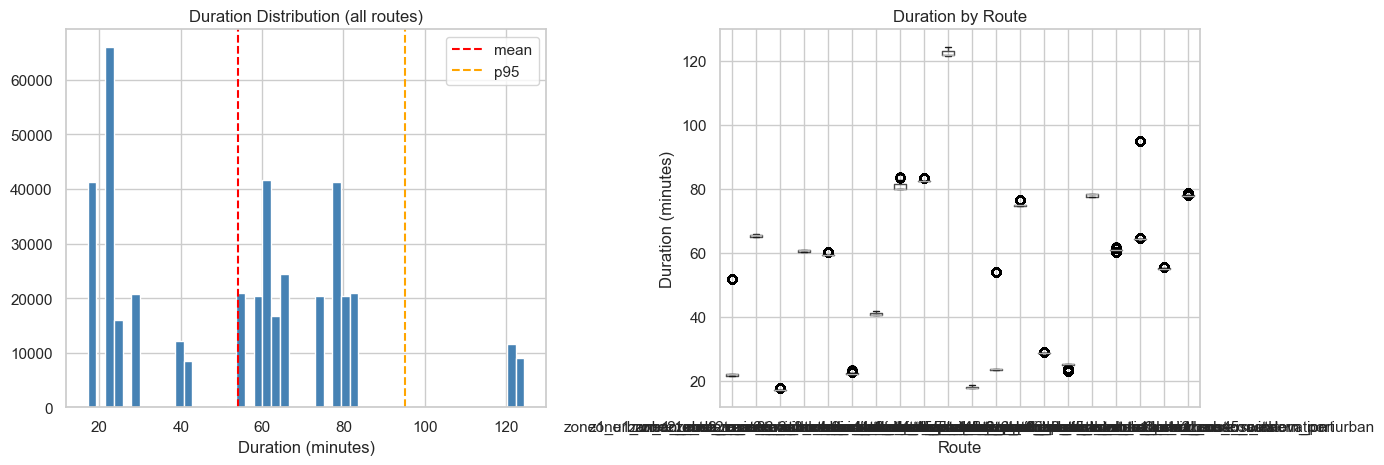

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
df["duration_minutes"].hist(bins=50, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Duration Distribution (all routes)")
axes[0].set_xlabel("Duration (minutes)")
axes[0].axvline(df["duration_minutes"].mean(), color="red", linestyle="--", label="mean")
axes[0].axvline(df["duration_minutes"].quantile(0.95), color="orange", linestyle="--", label="p95")
axes[0].legend()

# Per route boxplot
df.boxplot(column="duration_minutes", by="route_id", ax=axes[1], vert=True)
axes[1].set_title("Duration by Route")
axes[1].set_xlabel("Route")
axes[1].set_ylabel("Duration (minutes)")
plt.suptitle("")

plt.tight_layout()
plt.show()

## 7. Congestion Analysis

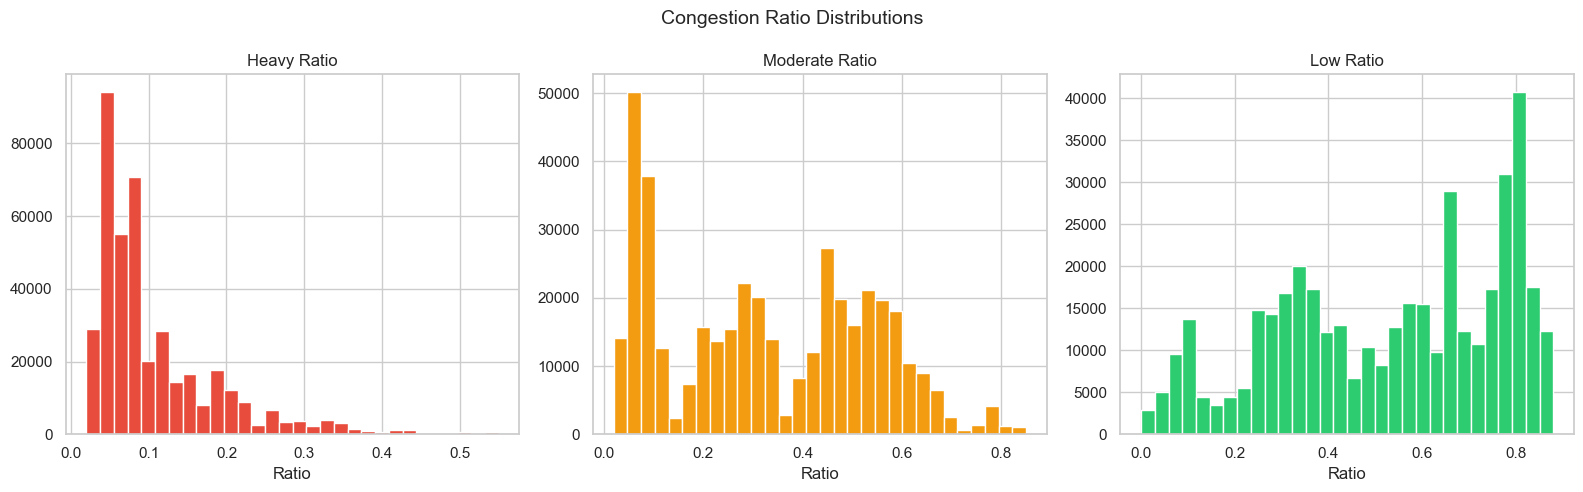

In [9]:
congestion_cols = ["congestion_heavy_ratio", "congestion_moderate_ratio", "congestion_low_ratio"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(congestion_cols):
    df[col].hist(bins=30, ax=axes[i], color=["#e74c3c", "#f39c12", "#2ecc71"][i], edgecolor="white")
    axes[i].set_title(col.replace("congestion_", "").replace("_", " ").title())
    axes[i].set_xlabel("Ratio")

plt.suptitle("Congestion Ratio Distributions", fontsize=14)
plt.tight_layout()
plt.show()

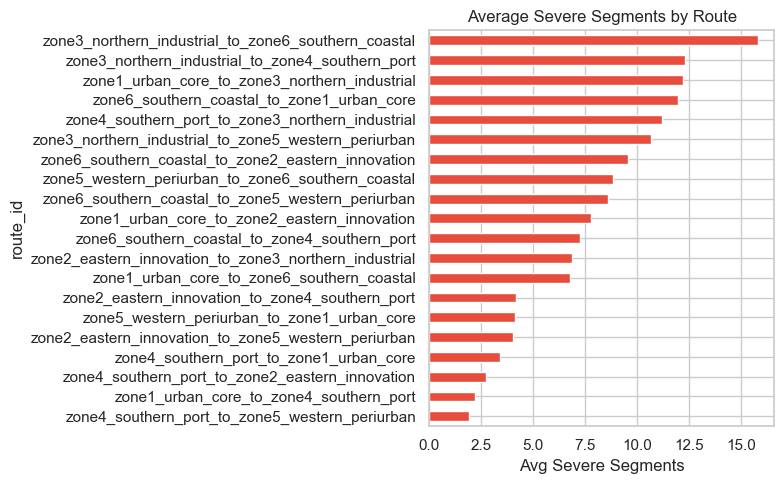

In [10]:
# Severe segments distribution
fig, ax = plt.subplots(figsize=(8, 5))
df.groupby("route_id")["congestion_severe_segments"].mean().sort_values().plot(
    kind="barh", ax=ax, color="#e74c3c"
)
ax.set_title("Average Severe Segments by Route")
ax.set_xlabel("Avg Severe Segments")
plt.tight_layout()
plt.show()

## 8. Hourly Heatmap (Route x Hour)

Xem pattern giao thong theo gio cua tung route — giup hieu baseline truoc khi train model.

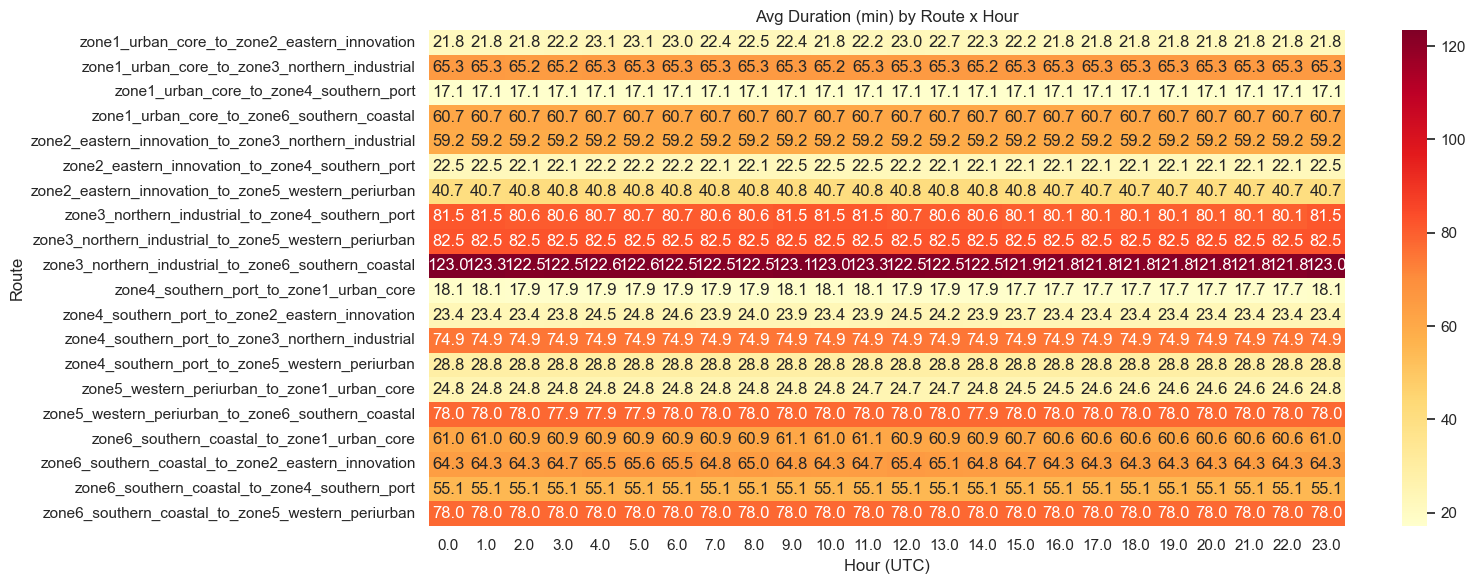

In [11]:
pivot = df.pivot_table(
    values="duration_minutes",
    index="route_id",
    columns="hour",
    aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax)
ax.set_title("Avg Duration (min) by Route x Hour")
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("Route")
plt.tight_layout()
plt.show()

## 9. Correlation Matrix

Xem cac features co tuong quan voi nhau khong — giup chon features cho model.

KeyError: "['distance_meter'] not in index"

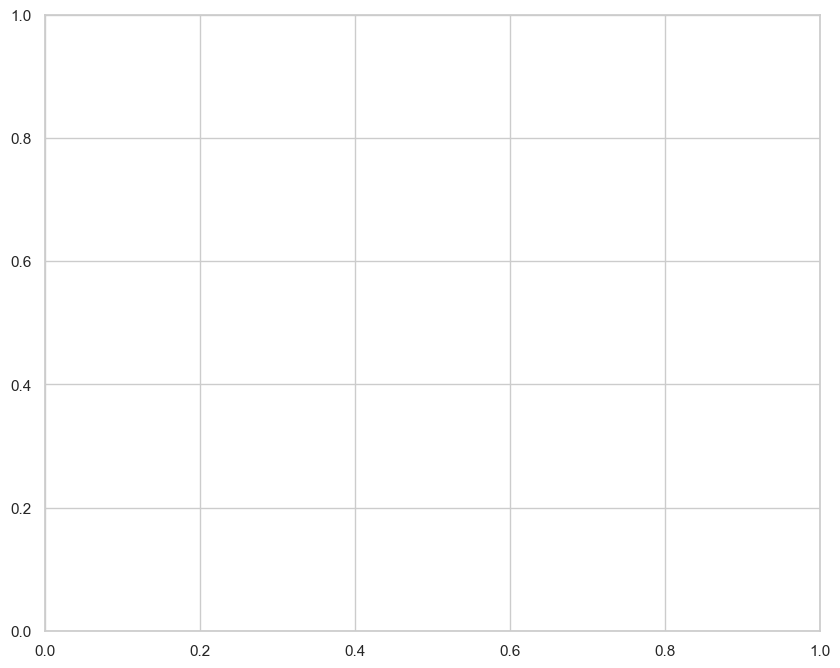

In [12]:
numeric_cols = [
    "distance_meter", "duration_minutes",
    "congestion_heavy_ratio", "congestion_moderate_ratio", "congestion_low_ratio",
    "congestion_severe_segments", "congestion_total_segments",
]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
    square=True, linewidths=0.5
)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## 10. Gold-level Aggregation Preview

Preview ket qua silver-to-gold aggregation truc tiep bang DuckDB.

In [ ]:
gold_preview = con.execute(f"""
    SELECT
        route_id,
        DATE_TRUNC('hour', timestamp_utc)                               AS hour_utc,
        COUNT(*)                                                         AS observation_count,
        AVG(duration_minutes)                                            AS avg_duration_minutes,
        PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY duration_minutes)  AS p95_duration_minutes,
        AVG(congestion_heavy_ratio)                                      AS avg_heavy_ratio,
        AVG(distance_meter / NULLIF(duration_ms, 0) * 1000 * 3.6)      AS avg_speed_kmh
    FROM read_parquet('{SILVER_PATH}', hive_partitioning := true)
    WHERE timestamp_utc IS NOT NULL
    GROUP BY route_id, DATE_TRUNC('hour', timestamp_utc)
    ORDER BY hour_utc DESC
    LIMIT 20
""").df()

gold_preview